# **Practical**

This project uses the Scikit-Learn Digits dataset (a smaller version of MNIST with 1,797
8
×
8
 images). We will walk through the data preparation, model training, performance comparison, and then answer the discussion questions.

**Step 1: Load and Visualize the Data**
First, we look at what we are actually classifying.

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time
import numpy as np

In [14]:
# Load the dataset
digits = load_digits()
X, y = digits.data, digits.target

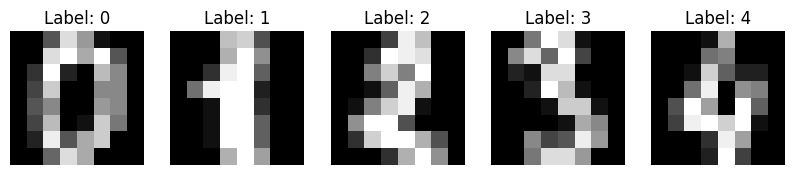

In [15]:
# Visualize the first few digits
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')
plt.show()

In [16]:
print(f"Dataset shape: {X.shape}") # 1797 samples, 64 features (8x8 pixels)

Dataset shape: (1797, 64)


**Interpretation:** Each image is an
8
×
8
grid of pixels, flattened into a vector of 64 features. Each pixel value represents grayscale intensity.

Step 2: Preprocessing (Scaling and Splitting)
# KNN relies on distance, so scaling is mandatory. Decision Trees do not strictly require it, but we will use scaled data for a fair comparison.

In [17]:
# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Interpretation:** We split the data 80/20. The StandardScaler ensures every pixel has a mean of 0 and a variance of 1, preventing pixels with higher intensity ranges from dominating the distance calculation.


Step 3: Training and Timing the Models
We will measure how long it takes to train and how long it takes to predict.

In [18]:
# --- KNN Model ---
knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
knn.fit(X_train_scaled, y_train)
knn_train_time = time.time() - start

start = time.time()
knn_preds = knn.predict(X_test_scaled)
knn_pred_time = time.time() - start

# --- Decision Tree Model ---
dt = DecisionTreeClassifier(random_state=42)
start = time.time()
dt.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start

start = time.time()
dt_preds = dt.predict(X_test_scaled)
dt_pred_time = time.time() - start

print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds):.4f}")
print(f"DT Accuracy:  {accuracy_score(y_test, dt_preds):.4f}")
print(f"\nKNN - Train: {knn_train_time:.4f}s, Predict: {knn_pred_time:.4f}s")
print(f"DT  - Train: {dt_train_time:.4f}s, Predict: {dt_pred_time:.4f}s")

KNN Accuracy: 0.9750
DT Accuracy:  0.8417

KNN - Train: 0.0031s, Predict: 0.0124s
DT  - Train: 0.0256s, Predict: 0.0007s


**Interpretation: You will likely notice KNN is significantly more accurate on this specific dataset, but it is much slower at the prediction phase than the Decision Tree.**

Step 4: Visualizing Decision Boundaries
Since we cannot plot 64 dimensions, we use PCA to reduce the data to 2 dimensions just for this visualization.

In [19]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_train_scaled)


In [20]:
# Re-train models on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=5).fit(X_reduced, y_train)
dt_2d = DecisionTreeClassifier().fit(X_reduced, y_train)


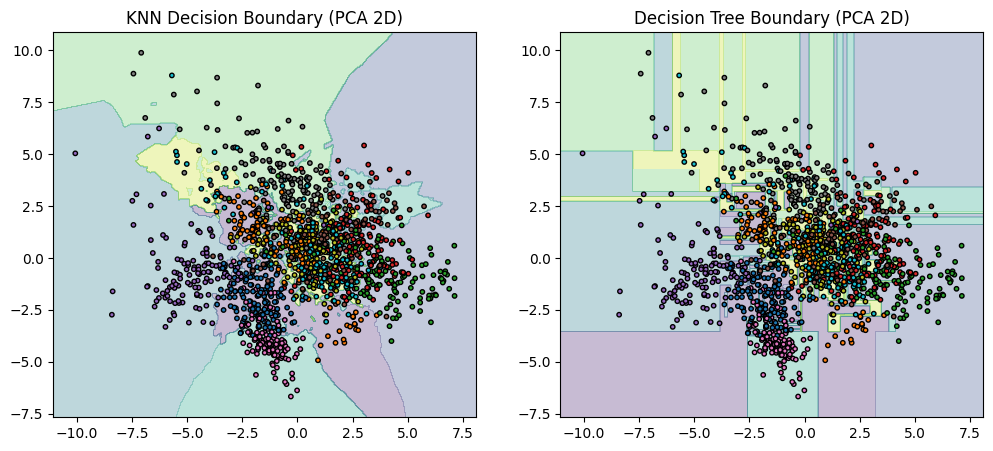

In [21]:
# Plotting function
def plot_boundary(model, title, ax):
    h = .05 # step size in mesh
    x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
    y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train, s=10, edgecolor='k', cmap='tab10')
    ax.set_title(title)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(knn_2d, "KNN Decision Boundary (PCA 2D)", ax1)
plot_boundary(dt_2d, "Decision Tree Boundary (PCA 2D)", ax2)
plt.show()

**Interpretation: Notice the shapes. KNN boundaries are often "organic" and curvy, whereas Decision Tree boundaries are made of horizontal and vertical lines (box-like).**

Step 5: Confusion Matrix Comparison
Let's see where the models get confused.

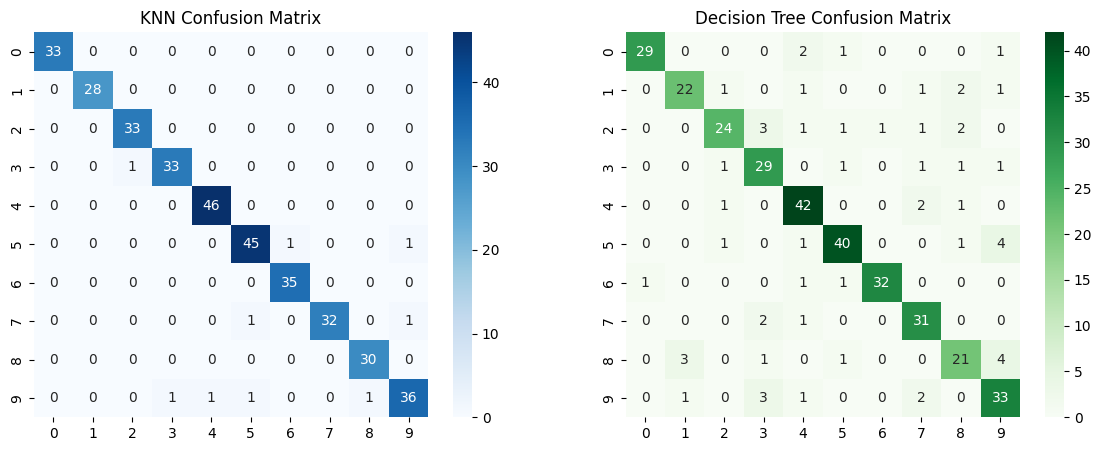

In [22]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title("KNN Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', ax=ax2, cmap='Greens')
ax2.set_title("Decision Tree Confusion Matrix")
plt.show()

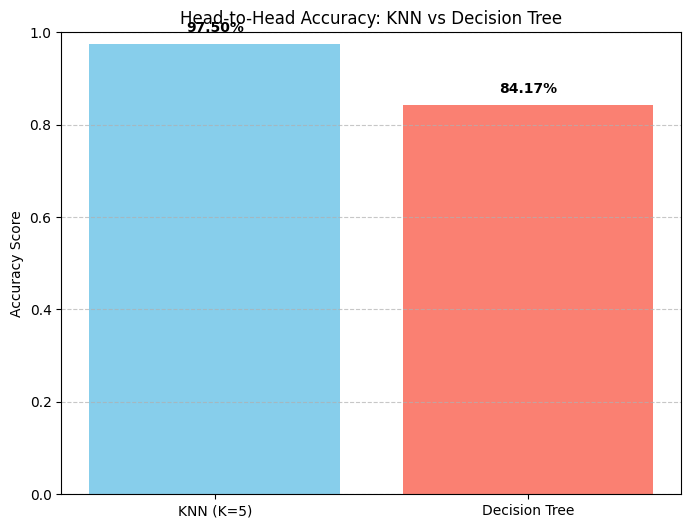

In [23]:
import matplotlib.pyplot as plt

# 1. Prepare the data
models = ['KNN (K=5)', 'Decision Tree']
accuracies = [accuracy_score(y_test, knn_preds), accuracy_score(y_test, dt_preds)]

# 2. Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon'])

# 3. Add details to make it readable
plt.ylim(0, 1.0) # Set y-axis from 0 to 100%
plt.ylabel('Accuracy Score')
plt.title('Head-to-Head Accuracy: KNN vs Decision Tree')

# Add the exact percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

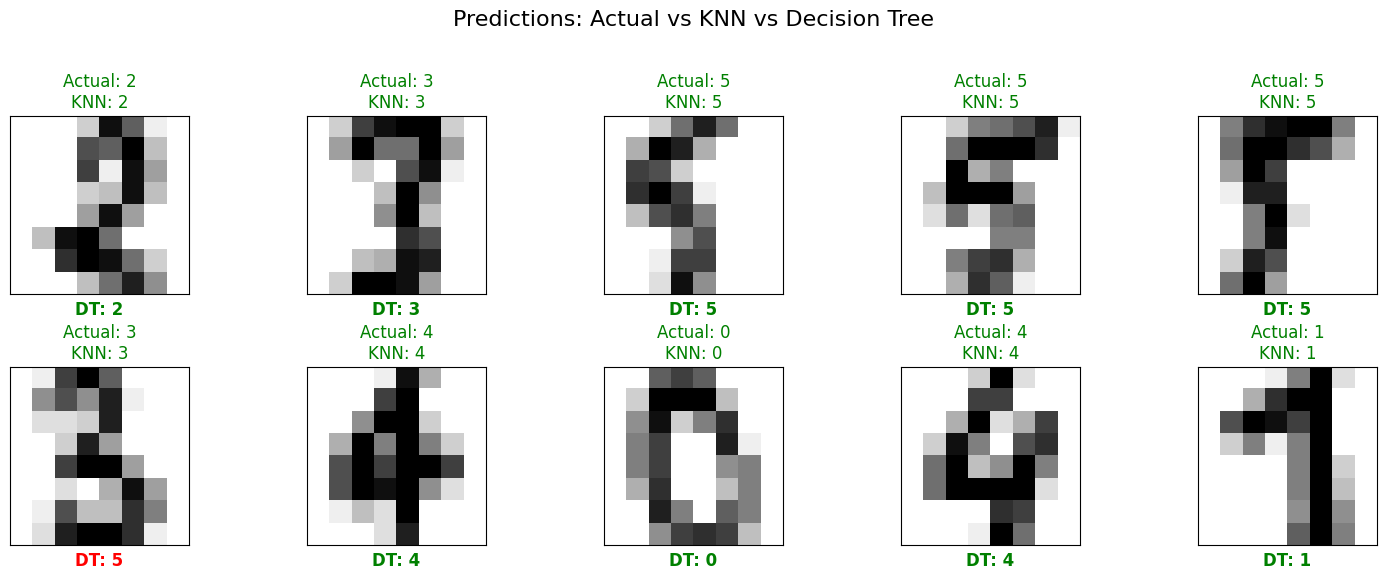

In [24]:
import numpy as np

# 1. Select a few random samples from the test set
num_samples = 10
indices = np.random.choice(len(X_test), num_samples)

# 2. Set up the visualization plot
plt.figure(figsize=(15, 6))
plt.suptitle("Predictions: Actual vs KNN vs Decision Tree", fontsize=16)

for i, idx in enumerate(indices):
    # Get the image data (unscaled for display)
    img = X_test[idx].reshape(8, 8)

    # Get the true label and the model predictions
    actual = y_test[idx]
    knn_pred = knn_preds[idx]
    dt_pred = dt_preds[idx]

    # Create subplots
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray_r') # gray_r makes it look like ink on paper

    # Logic for text color: Green if correct, Red if wrong
    knn_color = 'green' if knn_pred == actual else 'red'
    dt_color = 'green' if dt_pred == actual else 'red'

    plt.title(f"Actual: {actual}\nKNN: {knn_pred}", color=knn_color)
    plt.xlabel(f"DT: {dt_pred}", color=dt_color, fontsize=12, fontweight='bold')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



1.   **Model Reliability:** You will likely see that the KNN prediction is almost always green. KNN is very good at identifying the "shape" of the digit.
2.   **The "Why" of Errors:** If the Decision Tree (DT) is red, look closely at the image. Is the digit slanted? Is it drawn thicker than usual?
Example: If a "7" is drawn with a middle cross-bar, the Decision Tree might think it's a "2" or a "3" because its strict rules about pixel locations are being violated.

3. **Visual Similarity:** If you see a mistake where both models guess the same wrong number (e.g., both guess 8 for a 1), it usually means the image is very blurry or poorly drawn even for a human to distinguish easily.

4. **KNN's Strength:** Notice that even if a digit is shifted slightly, KNN usually gets it right because the cluster of pixels is still closer to other examples of that digit than to any other class.